# Intraday flow exploration (E-001)

Diagnostics of H-012 (rejected), for **hypothesis generation only**. Every pattern
here comes from development data and must be registered in
`HYPOTHESIS_LEDGER.md` before it is tested. The slices are logged as E-001.

Flow features are defined in `FEATURE_CATALOGUE.md` ("Trailing-window flow
features"). `zx_W` is `z30(x_W)`, the 30-day z-score of window net flow over
typical window volume. `resid_W` is `zx_W` orthogonalised to the H-012 return
benchmark within the period. Future returns are mid-to-mid (last trade) in bps.

In [1]:
from pathlib import Path
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
E = REPO / 'alpha-search' / 'reports' / 'intraday_flow_v1' / 'exploration'
univariate = pl.read_csv(E / 'univariate_ic.csv')
correlation = pl.read_csv(E / 'flow_return_correlation.csv')
residual = pl.read_csv(E / 'residual_flow_ic.csv')
deciles = pl.read_csv(E / 'decile_shapes.csv')
grid = pl.read_csv(E / 'divergence_grid.csv')
regime = pl.read_csv(E / 'regime_ic.csv')
fills = pl.read_csv(E / 'fill_delay_adverse_selection.csv')

SERIES = ['#2a78d6', '#eb6834', '#1baf7a']
INK, MUTED = '#2b2b2b', '#8a8a85'
WINDOWS = [15, 60, 240]
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False,
                     'axes.spines.right': False, 'grid.color': '#e6e6e3'})
pl.Config.set_tbl_rows(60)
pl.Config.set_float_precision(3)

polars.config.Config

## Controls

In [2]:
HORIZON = 15   # 5, 15 or 30 minutes

## 1. On its own, flow is a reversal signal, like returns

Mean monthly Spearman IC, 2023–May 2026 (left) and 2021–2022 (right).

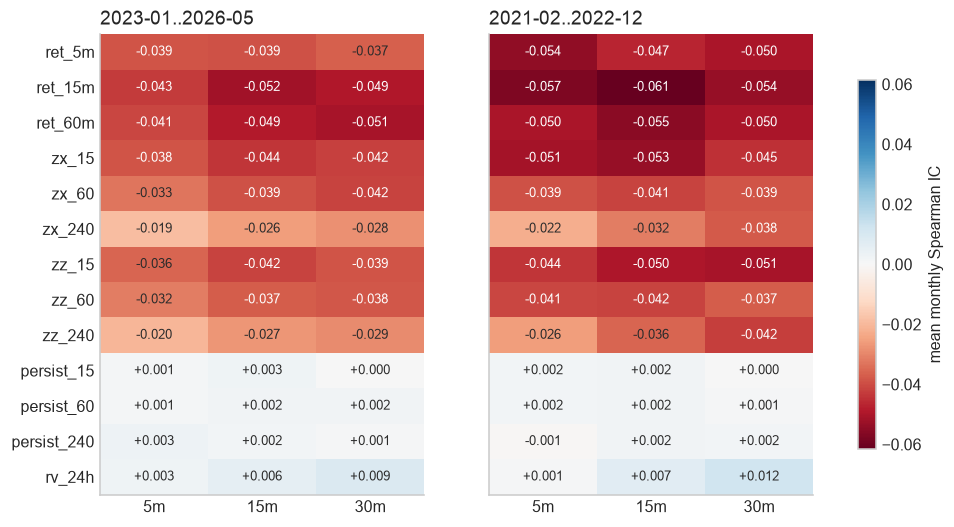

In [3]:
features = ['ret_5m', 'ret_15m', 'ret_60m', 'zx_15', 'zx_60', 'zx_240',
            'zz_15', 'zz_60', 'zz_240', 'persist_15', 'persist_60', 'persist_240', 'rv_24h']
fig, axes = plt.subplots(1, 2, figsize=(10, 5.2), sharey=True)
limit = univariate['mean_ic'].abs().max()
for ax, period in zip(axes, ['2023-01..2026-05', '2021-02..2022-12']):
    view = univariate.filter(pl.col('period') == period)
    values = np.array([[view.filter((pl.col('feature') == f) & (pl.col('horizon_minutes') == h))
                        ['mean_ic'][0] for h in (5, 15, 30)] for f in features])
    image = ax.imshow(values, cmap='RdBu', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_xticks(range(3), ['5m', '15m', '30m'])
    ax.set_yticks(range(len(features)), features)
    ax.grid(False)
    for i in range(len(features)):
        for j in range(3):
            ax.text(j, i, f'{values[i, j]:+.3f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(values[i, j]) > 0.6 * limit else INK)
    ax.set_title(period, loc='left')
fig.colorbar(image, ax=axes, shrink=0.8, label='mean monthly Spearman IC')
plt.show()

## 2. Why flow adds nothing: it mostly restates the same-window return

In [4]:
correlation.pivot(on='return', index=['period', 'flow'], values='spearman')

period,flow,ret_5m,ret_15m,ret_60m
str,str,f64,f64,f64
"""2021-02..2022-12""","""zx_15""",0.337,0.784,0.337
"""2021-02..2022-12""","""zx_60""",0.143,0.313,0.779
"""2021-02..2022-12""","""zx_240""",0.062,0.129,0.305
"""2023-01..2026-05""","""zx_15""",0.311,0.741,0.325
"""2023-01..2026-05""","""zx_60""",0.123,0.279,0.737
"""2023-01..2026-05""","""zx_240""",0.055,0.125,0.301


## 3. What is left after removing returns

IC of flow orthogonalised to the return benchmark. Positive means continuation.

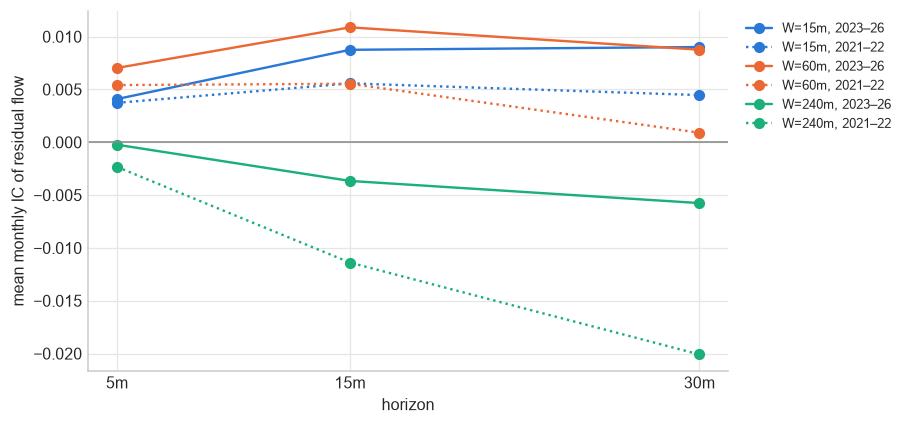

window_minutes,period,5,15,30
i64,str,f64,f64,f64
15,"""2021-02..2022-12""",0.923,0.954,0.973
60,"""2021-02..2022-12""",1.758,1.208,0.177
240,"""2021-02..2022-12""",-1.261,-3.387,-3.918
15,"""2023-01..2026-05""",1.841,3.774,3.735
60,"""2023-01..2026-05""",3.979,4.241,2.524
240,"""2023-01..2026-05""",-0.127,-1.298,-1.615


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for colour, w in zip(SERIES, WINDOWS):
    for style, period in (('-', '2023-01..2026-05'), (':', '2021-02..2022-12')):
        s = residual.filter((pl.col('window_minutes') == w) & (pl.col('period') == period)).sort('horizon_minutes')
        ax.plot(s['horizon_minutes'], s['mean_ic'], style, marker='o', color=colour,
                label=f'W={w}m, {period[:4]}{"–26" if period[0:4] == "2023" else "–22"}')
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks([5, 15, 30], ['5m', '15m', '30m'])
ax.set_xlabel('horizon')
ax.set_ylabel('mean monthly IC of residual flow')
ax.legend(frameon=False, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
residual.pivot(on='horizon_minutes', index=['window_minutes', 'period'], values='ic_t')

## 4. Shape: future return by decile

Mean future return in bps with ±2 day-clustered standard errors, test period.
Note the scale: everything is below 1 bps, against about 7 bps of costs even
with passive entry.

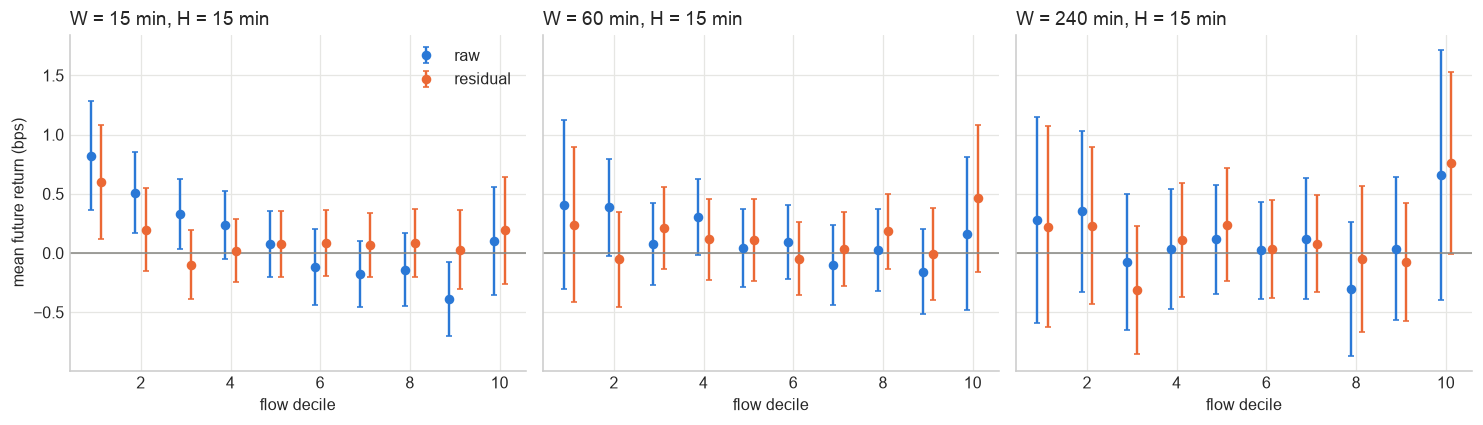

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, w in zip(axes, WINDOWS):
    for colour, kind in zip(SERIES, ['raw', 'residual']):
        s = deciles.filter((pl.col('window_minutes') == w) & (pl.col('kind') == kind)
                           & (pl.col('horizon_minutes') == HORIZON)).sort('decile')
        offset = -0.12 if kind == 'raw' else 0.12
        ax.errorbar(s['decile'] + offset, s['mean_future_bps'], yerr=2 * s['se_bps'], fmt='o',
                    color=colour, markersize=5, capsize=2, label=kind)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_title(f'W = {w} min, H = {HORIZON} min', loc='left')
    ax.set_xlabel('flow decile')
axes[0].set_ylabel('mean future return (bps)')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Flow–price divergence (return tercile × flow tercile), bps

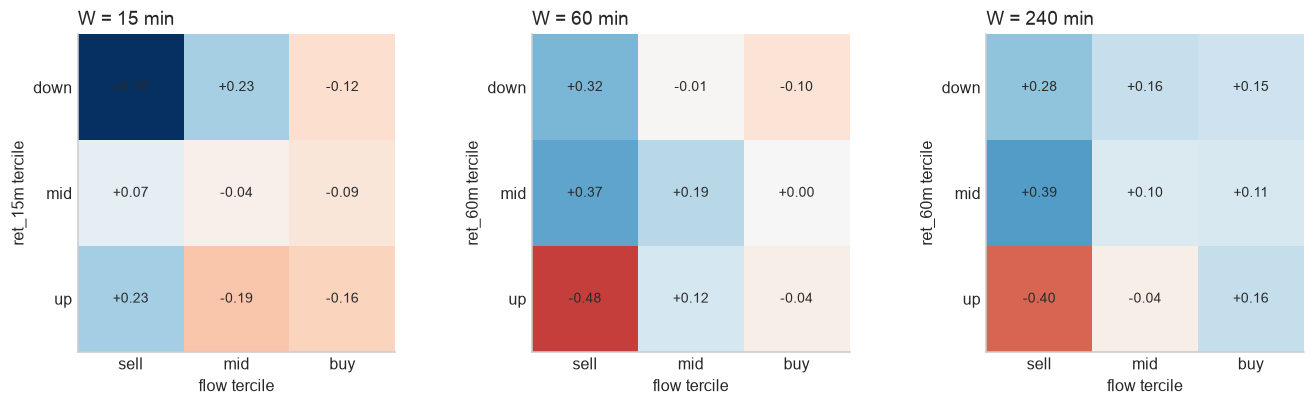

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
view = grid.filter(pl.col('horizon_minutes') == HORIZON)
limit = view['mean_future_bps'].abs().max()
for ax, w in zip(axes, WINDOWS):
    s = view.filter(pl.col('window_minutes') == w)
    values = np.array([[s.filter((pl.col('return_tercile') == i) & (pl.col('flow_tercile') == j))
                        ['mean_future_bps'][0] for j in (1, 2, 3)] for i in (1, 2, 3)])
    ax.imshow(values, cmap='RdBu', vmin=-limit, vmax=limit)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{values[i, j]:+.2f}', ha='center', va='center', fontsize=9, color=INK)
    ax.set_xticks(range(3), ['sell', 'mid', 'buy'])
    ax.set_yticks(range(3), ['down', 'mid', 'up'])
    ax.set_xlabel('flow tercile')
    ax.set_ylabel(s['return_feature'][0] + ' tercile')
    ax.set_title(f'W = {w} min', loc='left')
    ax.grid(False)
plt.tight_layout()
plt.show()

## 6. Regimes: volatility tercile (cuts from 2021–22) and year, W = 60

In [8]:
regime.filter((pl.col('window_minutes') == 60) & (pl.col('horizon_minutes') == HORIZON)).pivot(
    on='kind', index=['split', 'value'], values='mean_ic').sort('split', 'value')

split,value,raw,residual
str,i64,f64,f64
"""vol_tercile""",1,-0.041,0.021
"""vol_tercile""",2,-0.044,-0.007
"""vol_tercile""",3,-0.066,-0.041
"""year""",2023,-0.060,0.014
"""year""",2024,-0.039,0.008
"""year""",2025,-0.021,0.009
"""year""",2026,-0.034,0.014


## 7. Adverse selection of passive orders

Mid move after the decision, signed in the direction of the order, split by how
quickly the (H-012 v1) passive order filled. Filled orders are followed by
adverse moves; orders that never fill are the ones that would have made money.

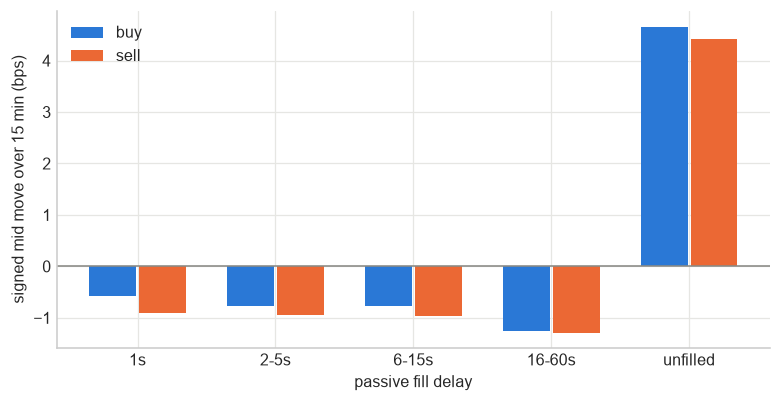

side,fill_delay,share,mean_signed_future_bps,se_bps
str,str,f64,f64,f64
"""buy""","""1s""",0.515,-0.574,0.083
"""buy""","""2-5s""",0.144,-0.777,0.129
"""buy""","""6-15s""",0.088,-0.768,0.141
"""buy""","""16-60s""",0.098,-1.248,0.158
"""buy""","""unfilled""",0.155,4.660,0.152
"""sell""","""1s""",0.503,-0.898,0.085
"""sell""","""2-5s""",0.151,-0.942,0.120
"""sell""","""6-15s""",0.093,-0.970,0.145
"""sell""","""16-60s""",0.098,-1.285,0.150


In [9]:
order = ['1s', '2-5s', '6-15s', '16-60s', 'unfilled']
view = fills.filter(pl.col('horizon_minutes') == HORIZON)
fig, ax = plt.subplots(figsize=(8, 3.8))
for colour, side, offset in ((SERIES[0], 'buy', -0.18), (SERIES[1], 'sell', 0.18)):
    s = view.filter(pl.col('side') == side)
    means = [s.filter(pl.col('fill_delay') == b)['mean_signed_future_bps'][0] for b in order]
    ax.bar(np.arange(len(order)) + offset, means, width=0.34, color=colour, label=side)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks(range(len(order)), order)
ax.set_xlabel('passive fill delay')
ax.set_ylabel(f'signed mid move over {HORIZON} min (bps)')
ax.legend(frameon=False)
plt.show()
view.select('side', 'fill_delay', 'share', 'mean_signed_future_bps', 'se_bps')